In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("=== 🚀 Starting PyTorch Pipeline ===")

# =========================
# 🖥️ Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# =========================
# ⚙️ Config
# =========================
DATA_DIR = "/teamspace/studios/this_studio/my_4k_dataset"
BATCH_SIZE = 32
IMG_SIZE = 512

# =========================
# 📦 Transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1,0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# 📦 Dataset
# =========================
dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

class_names = dataset.classes

# =========================
# 🔥 Focal Loss
# =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets):
        BCE = self.bce(inputs, targets)
        pt = torch.exp(-BCE)
        return self.alpha * (1 - pt) ** self.gamma * BCE

# =========================
# 🧠 Model
# =========================
model = models.densenet121(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

model = model.to(device)

# =========================
# ⚙️ Optimizer + Scheduler
# =========================
criterion = FocalLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# =========================
# 🚀 Training Loop
# =========================
def train_epoch(loader):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.float().unsqueeze(1).to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()
    return total_loss / len(loader)

# =========================
# 🚀 Phase 1
# =========================
print("=== Phase 1 Training ===")
for epoch in range(10):
    train_loss = train_epoch(train_loader)
    val_loss = eval_epoch(val_loader)
    scheduler.step()
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

# =========================
# 🚀 Phase 2 (Fine-tune)
# =========================
print("=== Phase 2 Fine-tuning ===")

for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)

for epoch in range(15):
    train_loss = train_epoch(train_loader)
    val_loss = eval_epoch(val_loader)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

# =========================
# 📊 Evaluation + TTA
# =========================
print("=== Evaluation with TTA ===")

tta_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

y_true, y_pred = [], []

model.eval()
for x, y in val_loader:
    x = x.to(device)

    preds = []
    for _ in range(5):
        aug_x = torch.stack([tta_transform(img.cpu()) for img in x])
        aug_x = aug_x.to(device)
        preds.append(model(aug_x).detach().cpu().numpy())

    avg_pred = np.mean(preds, axis=0)
    y_pred.extend((avg_pred > 0.5).astype(int).flatten())
    y_true.extend(y.numpy())

# =========================
# 📊 Metrics
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.show()

print(classification_report(y_true, y_pred))

=== 🚀 Starting PyTorch Pipeline ===
✅ Using device: cuda


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


=== Phase 1 Training ===
Epoch 1: Train Loss=0.0716, Val Loss=0.0256
Epoch 2: Train Loss=0.0225, Val Loss=0.0112
Epoch 3: Train Loss=0.0112, Val Loss=0.0077
Epoch 4: Train Loss=0.0121, Val Loss=0.0055
Epoch 5: Train Loss=0.0096, Val Loss=0.0044
Epoch 6: Train Loss=0.0079, Val Loss=0.0045
Epoch 7: Train Loss=0.0056, Val Loss=0.0037
Epoch 8: Train Loss=0.0049, Val Loss=0.0035
Epoch 9: Train Loss=0.0041, Val Loss=0.0033
Epoch 10: Train Loss=0.0049, Val Loss=0.0034
=== Phase 2 Fine-tuning ===
Epoch 1: Train Loss=0.0018, Val Loss=0.0005
Epoch 2: Train Loss=0.0004, Val Loss=0.0004
Epoch 3: Train Loss=0.0004, Val Loss=0.0004
Epoch 4: Train Loss=0.0001, Val Loss=0.0002
Epoch 5: Train Loss=0.0009, Val Loss=0.0004
Epoch 6: Train Loss=0.0003, Val Loss=0.0001
Epoch 7: Train Loss=0.0001, Val Loss=0.0002
Epoch 8: Train Loss=0.0001, Val Loss=0.0001
Epoch 9: Train Loss=0.0001, Val Loss=0.0001
Epoch 10: Train Loss=0.0001, Val Loss=0.0001
Epoch 11: Train Loss=0.0001, Val Loss=0.0001
Epoch 12: Train Loss

TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>

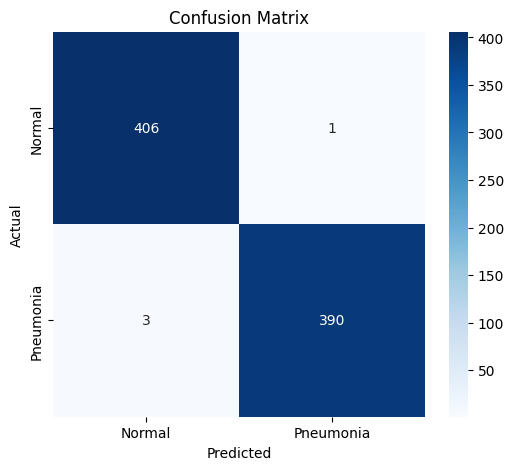

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       407
   Pneumonia       1.00      0.99      0.99       393

    accuracy                           0.99       800
   macro avg       1.00      0.99      0.99       800
weighted avg       1.00      0.99      0.99       800



In [3]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        
        outputs = model(x)
        preds = (outputs > 0.5).float()
        
        y_pred.extend(preds.cpu().numpy().flatten())
        y_true.extend(y.numpy())

# =========================
# 📊 Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =========================
# 📊 Classification Report
# =========================
print(classification_report(y_true, y_pred, target_names=class_names))

In [4]:
torch.save(model.state_dict(), "final_model.pth")

In [3]:
import torch
import torch.nn as nn
from torchvision import models

print("=== 🚀 Loading Saved Model ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize the base DenseNet121 architecture (no need to download ImageNet weights now)
model = models.densenet121(weights=None)

# 2. Rebuild the exact same custom classifier head you used during training
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

# 3. Load your saved weights into the architecture
# (Change the filename if it is named 'final_model (1).pth' in your directory)
model.load_state_dict(torch.load("final_model.pth", map_location=device))

model = model.to(device)
model.eval() # Set to evaluation mode for XAI
print("✅ Model weights loaded successfully! Ready for XAI.")

ModuleNotFoundError: No module named 'torchvision'

In [4]:
!pip install torchvision

   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   -- ------------------------------------- 0.3/3.7 MB ? eta -:--:--
   -- ------------------------------------- 0.3/3.7 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/3.7 MB 558.9 kB/s eta 0:00:06
   -------- ------------------------------- 0.8/3.7 MB 744.7 kB/s eta 0:00:04
   ----------------- ---------------------- 1.6/3.7 MB 1.3 MB/s eta 0:00:02
   -------------------- ------------------- 1.8/3.7 MB 1.4 MB/s eta 0:00:02
   ------------------------- -------------- 2.4/3.7 MB 1.6 MB/s eta 0:00:01
   ------------------------------- -------- 2.9/3.7 MB 1.6 MB/s eta 0:00:01
   ---------------------------------- ----- 3.1/3.7 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   --------------------------------------

  You can safely remove it manually.
  You can safely remove it manually.


In [2]:
import torch
import torch.nn as nn
from torchvision import models

print("=== 🚀 Loading Saved Model ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize the base DenseNet121 architecture (no need to download ImageNet weights now)
model = models.densenet121(weights=None)

# 2. Rebuild the exact same custom classifier head you used during training
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

# 3. Load your saved weights into the architecture
# (Change the filename if it is named 'final_model (1).pth' in your directory)
model.load_state_dict(torch.load("final_model (1).pth", map_location=device))

model = model.to(device)
model.eval() # Set to evaluation mode for XAI
print("✅ Model weights loaded successfully! Ready for XAI.")

=== 🚀 Loading Saved Model ===
✅ Model weights loaded successfully! Ready for XAI.


In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

print("=== 📦 Rebuilding Data Loader ===")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Update this path if your dataset is located somewhere else now
DATA_DIR = r"C:\Users\prakh\Downloads\archive (1)\my_4k_dataset"
BATCH_SIZE = 32
IMG_SIZE = 512

# 1. Recreate your validation transforms
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# 2. Load the dataset structure to get the class names
dataset = datasets.ImageFolder(DATA_DIR)
class_names = dataset.classes

# 3. Split the dataset exactly as you did during training
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Apply the validation transforms to the val_dataset
val_dataset.dataset.transform = val_transform

# 4. Recreate the val_loader
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ val_loader successfully recreated!")
print(f"Classes found: {class_names}")

=== 📦 Rebuilding Data Loader ===
✅ val_loader successfully recreated!
Classes found: ['Normal', 'Pneumonia']


=== 🚀 Starting Explainable AI Pipeline ===
Generating Grad-CAM...
Generating LIME...


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating RISE...


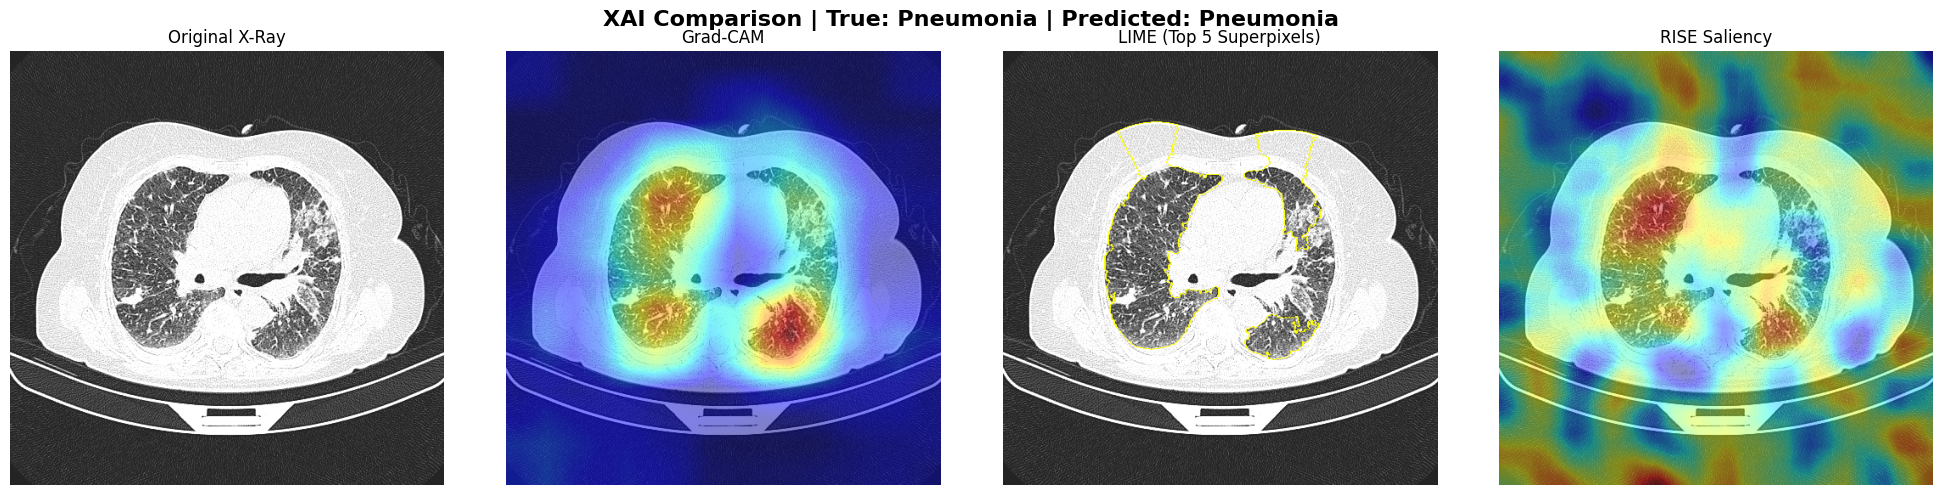

In [7]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import mark_boundaries
import lime
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

print("=== 🚀 Starting Explainable AI Pipeline ===")

# ==========================================
# 0. Get a Sample Image from your Val Loader
# ==========================================
for x, y in val_loader:
    sample_tensor = x[0].unsqueeze(0).to(device) # Shape: [1, 3, 512, 512]
    sample_label = int(y[0].item())
    break

# Convert PyTorch tensor [-1, 1] back to [0, 1] RGB image for plotting
sample_image_vis = sample_tensor[0].cpu().numpy().transpose(1, 2, 0)
sample_image_vis = np.clip((sample_image_vis * 0.5) + 0.5, 0, 1)


# ==========================================
# 1. Grad-CAM (Pure PyTorch)
# ==========================================
print("Generating Grad-CAM...")
class BinaryGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]
        
    def generate(self, x_tensor):
        self.model.eval()
        self.model.zero_grad()
        preds = self.model(x_tensor)
        
        # Logit trick for binary models
        p = torch.clamp(preds, 1e-7, 1.0 - 1e-7)
        logit = torch.log(p / (1 - p))
        
        pred_class = int(preds.item() > 0.5)
        pred_sign = 1.0 if pred_class == 1 else -1.0
        target_score = logit[0, 0] * pred_sign
        
        target_score.backward(retain_graph=True)
        pooled_grads = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        
        for i in range(activations.size(0)):
            activations[i, :, :] *= pooled_grads[i]
            
        heatmap = torch.mean(activations, dim=0).detach().cpu().numpy()
        heatmap = np.maximum(heatmap, 0) 
        if np.max(heatmap) > 0: heatmap /= np.max(heatmap)
        return heatmap, pred_class

cam = BinaryGradCAM(model, model.features.denseblock4)
gradcam_heatmap, pred_class = cam.generate(sample_tensor)

# Resize with PIL
heatmap_img = Image.fromarray(gradcam_heatmap)
try: resample_filter = Image.Resampling.BILINEAR
except AttributeError: resample_filter = Image.BILINEAR
gradcam_resized = np.array(heatmap_img.resize((512, 512), resample_filter))

# Colorize with Matplotlib
cmap = plt.get_cmap('jet')
gradcam_colored = cmap(gradcam_resized)[:, :, :3]
gradcam_overlay = np.clip((sample_image_vis * 0.5) + (gradcam_colored * 0.5), 0, 1)


# ==========================================
# 2. LIME (With SLIC Segmenter)
# ==========================================
print("Generating LIME...")
def predict_wrapper(images_numpy):
    batch_tensor = torch.tensor(images_numpy).permute(0, 3, 1, 2).float()
    batch_tensor = (batch_tensor - 0.5) / 0.5 
    batch_tensor = batch_tensor.to(device)
    model.eval()
    with torch.no_grad(): preds = model(batch_tensor).cpu().numpy()
    return np.hstack((1 - preds, preds))

explainer = lime_image.LimeImageExplainer()
segmenter = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)

explanation = explainer.explain_instance(
    sample_image_vis.astype('double'), predict_wrapper,
    top_labels=1, hide_color=0, num_samples=1000, segmentation_fn=segmenter
)
lime_temp, lime_mask = explanation.get_image_and_mask(
    explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
)


# ==========================================
# 3. RISE (Native PyTorch Interpolation)
# ==========================================
print("Generating RISE...")
def generate_masks_pytorch(N, s, p1):
    cell_size = np.ceil(np.array((512, 512)) / s)
    up_size = (s + 1) * cell_size
    grid = (torch.rand(N, 1, s, s) < p1).float()
    masks_up = F.interpolate(grid, size=(int(up_size[0]), int(up_size[1])), mode='bilinear', align_corners=False)
    masks = torch.empty((N, 1, 512, 512))
    for i in range(N):
        x, y = np.random.randint(0, int(cell_size[1])), np.random.randint(0, int(cell_size[0]))
        masks[i] = masks_up[i, :, y:y+512, x:x+512]
    return masks

def explain_with_rise(model, img_tensor, N=1000, s=12, p1=0.5):
    masks_tensor = generate_masks_pytorch(N, s, p1).to(device) 
    masked_images = img_tensor.repeat(N, 1, 1, 1) * masks_tensor
    preds = []
    with torch.no_grad():
        for i in range(0, N, 32):
            preds.extend(model(masked_images[i:i+32]).cpu().numpy().flatten())
    sal = np.tensordot(np.array(preds), masks_tensor.squeeze(1).cpu().numpy(), axes=([0], [0]))
    return sal / N / p1

rise_heatmap = explain_with_rise(model, sample_tensor)
rise_heatmap -= rise_heatmap.min()
rise_heatmap /= rise_heatmap.max()


# ==========================================
# 4. Plot Everything Side-by-Side
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f"XAI Comparison | True: {class_names[sample_label]} | Predicted: {class_names[pred_class]}", fontsize=16, fontweight='bold')

axes[0].imshow(sample_image_vis)
axes[0].set_title("Original X-Ray")
axes[0].axis('off')

axes[1].imshow(gradcam_overlay)
axes[1].set_title("Grad-CAM")
axes[1].axis('off')

axes[2].imshow(mark_boundaries(np.clip(lime_temp, 0, 1), lime_mask))
axes[2].set_title("LIME (Top 5 Superpixels)")
axes[2].axis('off')

axes[3].imshow(sample_image_vis)
axes[3].imshow(rise_heatmap, cmap='jet', alpha=0.45)
axes[3].set_title("RISE Saliency")
axes[3].axis('off')

plt.tight_layout()
plt.show()

=== 🚀 Starting Explainable AI Pipeline ===
Generating Grad-CAM...
Generating LIME...


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating RISE (CPU Optimized)...
  -> Processing RISE masks 0/300...
  -> Processing RISE masks 32/300...
  -> Processing RISE masks 64/300...
  -> Processing RISE masks 96/300...
  -> Processing RISE masks 128/300...
  -> Processing RISE masks 160/300...
  -> Processing RISE masks 192/300...
  -> Processing RISE masks 224/300...
  -> Processing RISE masks 256/300...
  -> Processing RISE masks 288/300...
  -> Compiling RISE heatmap...


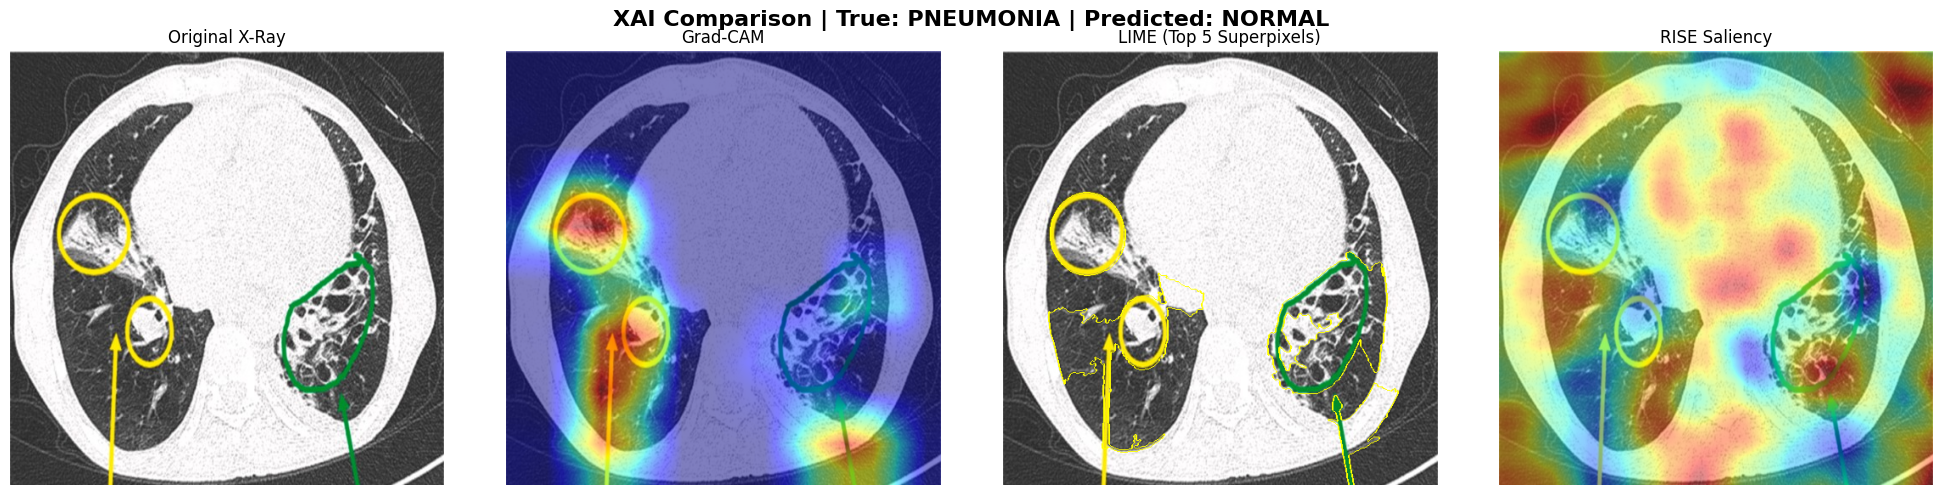

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from skimage.segmentation import mark_boundaries
import lime
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

print("=== 🚀 Starting Explainable AI Pipeline ===")

# ==========================================
# 0. Set your Image Path and Configuration
# ==========================================
IMAGE_PATH = r"C:\Users\prakh\Downloads\xaistage1\Screenshot 2026-03-26 193016.jpg"
TRUE_LABEL_NAME = "PNEUMONIA" # Change to "NORMAL" if testing a normal image

IMG_SIZE = 512
class_names = ['NORMAL', 'PNEUMONIA']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load and Preprocess the Image
def load_image(img_path):
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    tensor = transform(img).unsqueeze(0).to(device)
    return tensor

sample_tensor = load_image(IMAGE_PATH)

# Convert PyTorch tensor [-1, 1] back to [0, 1] RGB image for plotting
sample_image_vis = sample_tensor[0].cpu().numpy().transpose(1, 2, 0)
sample_image_vis = np.clip((sample_image_vis * 0.5) + 0.5, 0, 1)

# ==========================================
# 1. Grad-CAM (Pure PyTorch)
# ==========================================
print("Generating Grad-CAM...")
class BinaryGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]
        
    def generate(self, x_tensor):
        self.model.eval()
        self.model.zero_grad()
        preds = self.model(x_tensor)
        
        # Logit trick for binary models
        p = torch.clamp(preds, 1e-7, 1.0 - 1e-7)
        logit = torch.log(p / (1 - p))
        
        pred_class_idx = int(preds.item() > 0.5)
        pred_sign = 1.0 if pred_class_idx == 1 else -1.0
        target_score = logit[0, 0] * pred_sign
        
        target_score.backward(retain_graph=True)
        pooled_grads = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        
        for i in range(activations.size(0)):
            activations[i, :, :] *= pooled_grads[i]
            
        heatmap = torch.mean(activations, dim=0).detach().cpu().numpy()
        heatmap = np.maximum(heatmap, 0) 
        if np.max(heatmap) > 0: heatmap /= np.max(heatmap)
        return heatmap, pred_class_idx

cam = BinaryGradCAM(model, model.features.denseblock4)
gradcam_heatmap, pred_class_idx = cam.generate(sample_tensor)

# Resize with PIL
heatmap_img = Image.fromarray(gradcam_heatmap)
try: resample_filter = Image.Resampling.BILINEAR
except AttributeError: resample_filter = Image.BILINEAR
gradcam_resized = np.array(heatmap_img.resize((IMG_SIZE, IMG_SIZE), resample_filter))

# Colorize with Matplotlib
cmap = plt.get_cmap('jet')
gradcam_colored = cmap(gradcam_resized)[:, :, :3]
gradcam_overlay = np.clip((sample_image_vis * 0.5) + (gradcam_colored * 0.5), 0, 1)

# ==========================================
# 2. LIME (With SLIC Segmenter)
# ==========================================
print("Generating LIME...")
def predict_wrapper(images_numpy):
    batch_tensor = torch.tensor(images_numpy).permute(0, 3, 1, 2).float()
    batch_tensor = (batch_tensor - 0.5) / 0.5 
    batch_tensor = batch_tensor.to(device)
    model.eval()
    with torch.no_grad(): preds = model(batch_tensor).cpu().numpy()
    return np.hstack((1 - preds, preds))

explainer = lime_image.LimeImageExplainer()
segmenter = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)

explanation = explainer.explain_instance(
    sample_image_vis.astype('double'), predict_wrapper,
    top_labels=1, hide_color=0, num_samples=1000, segmentation_fn=segmenter
)
lime_temp, lime_mask = explanation.get_image_and_mask(
    explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
)

# ==========================================
# 3. RISE (CPU-Optimized Batching)
# ==========================================
print("Generating RISE (CPU Optimized)...")
def generate_masks_pytorch(N, s, p1):
    cell_size = np.ceil(np.array((IMG_SIZE, IMG_SIZE)) / s)
    up_size = (s + 1) * cell_size
    grid = (torch.rand(N, 1, s, s) < p1).float()
    masks_up = F.interpolate(grid, size=(int(up_size[0]), int(up_size[1])), mode='bilinear', align_corners=False)
    masks = torch.empty((N, 1, IMG_SIZE, IMG_SIZE))
    for i in range(N):
        x, y = np.random.randint(0, int(cell_size[1])), np.random.randint(0, int(cell_size[0]))
        masks[i] = masks_up[i, :, y:y+IMG_SIZE, x:x+IMG_SIZE]
    return masks

def explain_with_rise_cpu(model, img_tensor, N=300, s=12, p1=0.5):
    masks_tensor = generate_masks_pytorch(N, s, p1).to(device) 
    preds = []
    batch_size = 16 # Small batch to prevent RAM freezing
    
    with torch.no_grad():
        for i in range(0, N, batch_size):
            if i % 32 == 0: print(f"  -> Processing RISE masks {i}/{N}...")
            batch_masks = masks_tensor[i:i+batch_size]
            batch_images = img_tensor.repeat(batch_masks.size(0), 1, 1, 1) * batch_masks
            preds.extend(model(batch_images).cpu().numpy().flatten())
            
    print("  -> Compiling RISE heatmap...")
    sal = np.tensordot(np.array(preds), masks_tensor.squeeze(1).cpu().numpy(), axes=([0], [0]))
    return sal / N / p1

rise_heatmap = explain_with_rise_cpu(model, sample_tensor, N=300)
rise_heatmap -= rise_heatmap.min()
rise_heatmap /= rise_heatmap.max()

# ==========================================
# 4. Plot Everything Side-by-Side
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
pred_name = class_names[pred_class_idx]
fig.suptitle(f"XAI Comparison | True: {TRUE_LABEL_NAME} | Predicted: {pred_name}", fontsize=16, fontweight='bold')

axes[0].imshow(sample_image_vis)
axes[0].set_title("Original X-Ray")
axes[0].axis('off')

axes[1].imshow(gradcam_overlay)
axes[1].set_title("Grad-CAM")
axes[1].axis('off')

axes[2].imshow(mark_boundaries(np.clip(lime_temp, 0, 1), lime_mask))
axes[2].set_title("LIME (Top 5 Superpixels)")
axes[2].axis('off')

axes[3].imshow(sample_image_vis)
axes[3].imshow(rise_heatmap, cmap='jet', alpha=0.45)
axes[3].set_title("RISE Saliency")
axes[3].axis('off')

plt.tight_layout()
plt.show()